# RNN vs LSTM for Text Classification

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

In [2]:
# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

In [3]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [95]:
# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Load and Explore Data

In [96]:
path = './dataset/Combined Data.csv'
df = pd.read_csv(path)
print('=' * 60)
print('Dataset Overview'.upper())
print('=' * 60)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

DATASET OVERVIEW
Shape: (53043, 3)
Columns: ['Unnamed: 0', 'statement', 'status']


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [97]:
df.isnull().sum()

Unnamed: 0      0
statement     362
status          0
dtype: int64

In [98]:
df.dropna(inplace=True)

In [99]:
df.isnull().sum()

Unnamed: 0    0
statement     0
status        0
dtype: int64

In [100]:
df.shape

(52681, 3)

In [101]:
# Text analysis
df['text_length'] = df['statement'].apply(lambda x: len(x))
df['word_count'] = df['statement'].apply(lambda x: len(x.split()))
df[['text_length', 'word_count']].describe()

,text_length,word_count
count,52681.000000,52681.000000
mean,578.713863,113.158729
std,846.269078,163.735305
min,2.000000,1.000000
25%,80.000000,15.000000
50%,317.000000,62.000000
75%,752.000000,148.000000
max,32759.000000,6300.000000


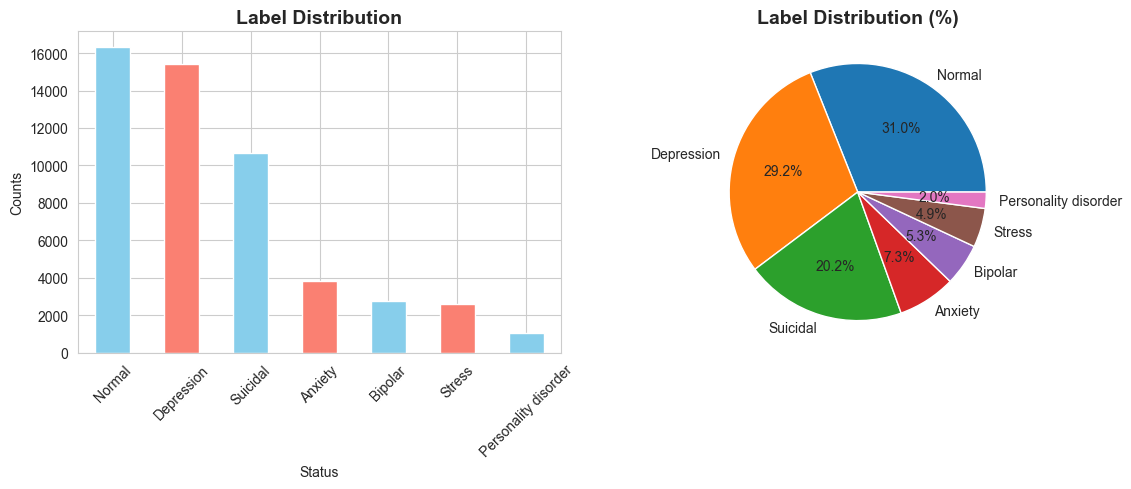

In [102]:
# Visualize label distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
df['status'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Label Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Counts')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(df['status'].value_counts().values, labels=df['status'].value_counts().index, autopct='%1.1f%%')
axes[1].set_title('Label Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()


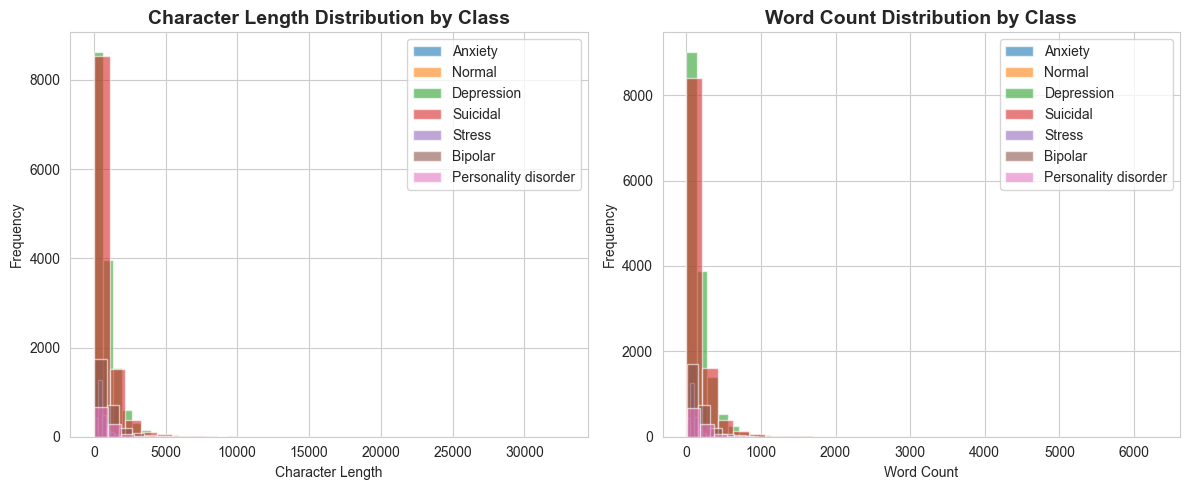

In [103]:
# Text length distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Character length
for label in df['status'].unique():
    subset = df[df['status'] == label]['text_length']
    axes[0].hist(subset, alpha=0.6, label=label, bins=30)
axes[0].set_title('Character Length Distribution by Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Word count
for label in df['status'].unique():
    subset = df[df['status'] == label]['word_count']
    axes[1].hist(subset, alpha=0.6, label=label, bins=30)
axes[1].set_title('Word Count Distribution by Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()

In [104]:
# Sample texts from each class
print('=' * 60)
print('SAMPLE TEXTS FROM EACH CLASS')
print('=' * 60)
for label in df['status'].unique():
    print(f'\n---{label.upper()}---')
    samples = df[df['status'] == label]['statement'].head(1).tolist()
    print(samples)

SAMPLE TEXTS FROM EACH CLASS

---ANXIETY---
['oh my gosh']

---NORMAL---
['Gr gr dreaming of ex crush to be my game, God']

---DEPRESSION---
['I recently went through a breakup and she said she still wants to be friends so I said I can try doing that but when she talks to me about things it always hurts. I just want to lose feelings so all this pain can stop it hurts so much and I cannot even cry about it. I do not want to hurt her because she said she does not want to never speak to me again but I do not know what to do here. When we were together she always hurt me so I do not know why I still love her. I wish we never met it would be much less painful How do I lose feelings?']

---SUICIDAL---
["I am so exhausted of this. Just when I think I can finally rest, just when I think maybe things are starting to settle, another hurdle comes flying at me. This month alone we found out my mum could be dying, my girlfriend left me, my parents revealed that they wanted a divorce, my grandad was

## Data Preprocessing

In [105]:
import re
import string

class TextPreprocessor:

    def __init__(self, max_vocab_size=10000, embedding_dim=100, max_seq_length=100):
        self.max_vocab_size = max_vocab_size
        self.embedding_dim = embedding_dim
        self.max_seq_length = max_seq_length
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}
        self.vocab_size = 2
        
    
    def clean_text(self, text):
        text = text.lower()
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        # Remove user mentionis and hashhtags
        text = re.sub(r'\@\w+|\#', '', text)
        # Remove punctuation
        text = text.translate(str.maketrans('', '', string.punctuation))
        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        return text


    def build_vocab(self, texts):
        word_counts = Counter()
        for text in texts:
            cleaned_text = self.clean_text(text)
            words = cleaned_text.split()
            word_counts.update(words)

        most_common = word_counts.most_common(self.max_vocab_size - 2)
        for word, frequency in most_common:
            if word not in self.word2idx.keys():
                self.word2idx[word] = self.vocab_size
                self.idx2word[self.vocab_size] = word
                self.vocab_size += 1
        
        print(f"Vocab size: {self.vocab_size}")


    def text_to_sequence(self, text):
        cleaned_text = self.clean_text(text)
        words = cleaned_text.split()
        sequence = [self.word2idx.get(word, self.word2idx['<UNK>']) for word in words]
        if len(sequence) > self.max_seq_length:
            sequence = sequence[:self.max_seq_length]
        
        return sequence
    

    def encode_texts(self, texts):
        return [self.text_to_sequence(text) for text in texts]

In [106]:
preprocessor = TextPreprocessor()
print('=' * 60)
print("PREPROCESSINGI")
print('=' * 60)

# Prepare labels
label_encoder = {label: idx for idx, label in enumerate(df['status'].unique().tolist())}
label_decoder = {idx: label for label, idx in label_encoder.items()}
print(label_encoder)
print(label_decoder)
df['status'] = df['status'].map(label_encoder)
df.head()

PREPROCESSINGI
{'Anxiety': 0, 'Normal': 1, 'Depression': 2, 'Suicidal': 3, 'Stress': 4, 'Bipolar': 5, 'Personality disorder': 6}
{0: 'Anxiety', 1: 'Normal', 2: 'Depression', 3: 'Suicidal', 4: 'Stress', 5: 'Bipolar', 6: 'Personality disorder'}


,Unnamed: 0,statement,status,text_length,word_count
0,0,oh my gosh,0,10,3
1,1,"trouble sleeping, confused mind, restless hear...",0,64,10
2,2,"All wrong, back off dear, forward doubt. Stay ...",0,78,14
3,3,I've shifted my focus to something else but I'...,0,61,11
4,4,"I'm restless and restless, it's been a month n...",0,72,14


In [28]:
# Split data
X = df['statement'].values
y = df['status'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

print(f'Train size: {len(X_train)}')
print(f'Validation size: {len(X_val)}')
print(f'Test size: {len(X_test)}')

Train size: 42144
Validation size: 5268
Test size: 5269


In [33]:
# Build vocabulary on training data only
preprocessor.build_vocab(X_train)

# Encode all splits
X_train_encoded = preprocessor.encode_texts(X_train)
X_val_encoded = preprocessor.encode_texts(X_val)
X_test_encoded = preprocessor.encode_texts(X_test)

print(f'Example encoded sequence: {X_train_encoded[0]}')
print(f'Example original text: {X_train[0]}')
print(label_encoder.get(y_train[0]))

Vocab size: 10000
Example encoded sequence: [2, 13, 40, 165, 3, 100, 1125, 305, 4, 60, 756, 153, 86, 243, 44, 17, 2, 295, 38, 2, 15, 159, 8, 27, 270, 9, 546, 931, 21, 137, 240, 321, 108, 5, 436, 352, 16, 33, 7, 776, 77, 3201, 1236, 2, 15, 1354, 4, 118, 82, 83, 23, 676, 2, 29, 25, 2, 944, 6, 2038, 23, 21, 411, 4, 2, 15, 788, 2, 47, 667, 8, 2, 125, 368, 20, 26, 3202, 3, 86]
Example original text: I have been trying to make plans recently and she keeps having things come up but i understand because i am doing it on kind of short notice. This last little bit after the break happened in about a 8 day span. TLDR: I am awkward and need some help with relationships. I feel like i ruined my chances with this girl and i am hoping i can fix it. I also may just be overreacting to things.
1


## Dataset and Dataloader

In [34]:
class TextDataset(Dataset):
    
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels


    def __len__(self):
        return len(self.sequences)


    def __getitem__(self, index):
        return (
            torch.tensor(self.sequences[index], dtype=torch.long),
            torch.tensor(self.labels[index], dtype=torch.long)
        )

In [35]:
def collate_fn(batch):
    """Custom collate function to pad sequences"""
    sequences, labels = zip(*batch)
    sequences_padded = pad_sequence(sequences, batch_first=True, padding_value=0)
    labels = torch.stack(labels)
    return sequences_padded, labels

In [ ]:
# Create datasets
train_dataset = TextDataset(X_train_encoded, y_train)
val_dataset = TextDataset(X_val_encoded, y_val)
test_dataset = TextDataset(X_test_encoded, y_test)

# Create dataloaders
BATCH_SIZE = 64

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

print(f"\nNumber of batches : Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")



Number of batches : Train: 659, Val: 83, Test: 83


## Model Architectures

In [56]:
class SimpleRNNModel(nn.Module):
    """
    Simple RNN for text classification
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers=1, dropout=0.3):
        super(SimpleRNNModel, self).__init__()
        
        self.embedding = nn.Embedding (
            vocab_size,
            embedding_dim
        )
        self.rnn = nn.RNN (
            embedding_dim,
            hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)


    def forward(self, x):
        # x: (batch_size, seq_len)
        embedded = self.dropout(self.embedding(x))  # (batch_size, seq_len, embedding_dim)
        output, hidden = self.rnn(embedded)  # output: (batch_size, seq_len, hidden_dim)
        
        # Use last hidden state
        hidden = hidden[-1]  # (batch_size, hidden_dim)
        hidden = self.dropout(hidden)
        
        out = self.fc(hidden)  # (batch_size, output_dim)
        return out

In [57]:
class LSTMModel(nn.Module):
    """LSTM for text classification"""
    
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, 
                 n_layers=1, dropout=0.3):
        super(LSTMModel, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim, 
            hidden_dim, 
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        # x: (batch_size, seq_len)
        embedded = self.dropout(self.embedding(x))  # (batch_size, seq_len, embedding_dim)
        output, (hidden, cell) = self.lstm(embedded)  # output: (batch_size, seq_len, hidden_dim)
        
        # Use last hidden state
        hidden = hidden[-1]  # (batch_size, hidden_dim)
        hidden = self.dropout(hidden)
        
        out = self.fc(hidden)  # (batch_size, output_dim)
        return out

In [74]:
class BiLSTMModel(nn.Module):
    """Bidirectional LSTM model for text classification."""
    
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, dropout=0.3):
        super(BiLSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, num_layers=1, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        # Note: hidden_dim * 2 because bidirectional concatenates forward and backward hidden states
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
    
    def forward(self, x):
        # x: (batch_size, seq_len)
        embedded = self.embedding(x)  # (batch_size, seq_len, embedding_dim)
        output, (hidden, cell) = self.lstm(embedded)  
        # hidden: (num_layers * num_directions, batch_size, hidden_dim)
        # For bidirectional: hidden[-2] is forward, hidden[-1] is backward
        # Concatenate the final forward and backward hidden states
        hidden_concat = torch.cat((hidden[-2], hidden[-1]), dim=1)  # (batch_size, hidden_dim * 2)
        dropped = self.dropout(hidden_concat)
        logits = self.fc(dropped)  # (batch_size, num_classes)
        return logits


In [75]:
# Model configuration
VOCAB_SIZE = preprocessor.vocab_size
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
OUTPUT_DIM = len(label_encoder)
N_LAYERS = 2
DROPOUT = 0.3

# Initialize models
rnn_model = SimpleRNNModel(
    VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT
).to(device)

lstm_model = LSTMModel(
    VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT
).to(device)

bilstm_model = BiLSTMModel(
    VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, DROPOUT
).to(device)

# Count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 60)
print("MODEL ARCHITECTURES")
print("=" * 60)
print(f"\n📊 Simple RNN Parameters: {count_parameters(rnn_model):,}")
print(f"📊 LSTM Parameters: {count_parameters(lstm_model):,}")

print(f"\n🔹 Simple RNN Architecture:")
print(rnn_model)

print(f"\n🔹 LSTM Architecture:")
print(lstm_model)

print(f"\n🔹 Bidirectional LSTM Architecture:")
bilstm_params = count_parameters(bilstm_model)
print(bilstm_model)
print(f"  Bidirectional LSTM: {bilstm_params:,}")



MODEL ARCHITECTURES

📊 Simple RNN Parameters: 1,512,199
📊 LSTM Parameters: 2,203,399

🔹 Simple RNN Architecture:
SimpleRNNModel(
  (embedding): Embedding(10000, 128)
  (rnn): RNN(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=256, out_features=7, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

🔹 LSTM Architecture:
LSTMModel(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=7, bias=True)
)

🔹 Bidirectional LSTM Architecture:
BiLSTMModel(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (lstm): LSTM(128, 256, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=7, bias=True)
)
  Bidirectional LSTM: 2,074,119


## Train

In [59]:
class Trainer:
    """
    Handles training and evaluation
    """

    def __init__(self, model, model_name, device):
        self.model = model
        self.model_name = model_name
        self.device = device
        self.history = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'train_time': [],
        }

    def train_epoch(self, dataloader, criterion, optimizer):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0
        for sequences, labels in dataloader:
            sequences = sequences.to(self.device)
            labels = labels.to(self.device)

            # Forward pass
            optimizer.zero_grad()
            outputs = self.model(sequences)
            loss = criterion(outputs, labels)

            # Bacward pass
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=5)

            optimizer.step()

            # Calculate accuracy
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(dataloader)
        accuracy = correct / total * 100
        return avg_loss, accuracy
    

    def evaluate(self, dataloader, criterion):
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for sequences, labels in dataloader:
                sequences = sequences.to(self.device)
                labels = labels.to(self.device)

                outputs = self.model(sequences)
                loss = criterion(outputs, labels)

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                total_loss += loss.item()
        avg_loss = total_loss / len(dataloader)
        accuracy = correct / total * 100
        return avg_loss, accuracy
    
    def train(self, train_loader, val_loader, epochs, learning_rate):
        """Full training loop"""
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.model.parameters(), lr=learning_rate)

        print(f'=' * 60)
        print(f'Training {self.model_name}')
        print(f'=' * 60)

        for epoch in range(epochs):
            start_time = time.time()

            # Train
            train_loss, train_acc = self.train_epoch(
                train_loader, criterion, optimizer
            )

            # Validate
            val_loss, val_acc = self.evaluate(
                val_loader, criterion
            )

            epoch_time = time.time() - start_time

            # Store history
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            self.history['train_time'].append(epoch_time)

            # Print progress
            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
                  f"Time: {epoch_time:.2f}s")
        
        print(f"\n✅ Training completed for {self.model_name}")
        return self.history



## Train Both Models

In [79]:
EPOCHS = 20
LEARNING_RATE = 0.001

# Train Simple RNN
rnn_trainer = Trainer(rnn_model, 'Simple RNN', device)
rnn_history = rnn_trainer.train(train_loader, val_loader, EPOCHS, LEARNING_RATE)

# Train LSTM
lstm_trainer = Trainer(lstm_model, 'LSTM', device)
lstm_history = lstm_trainer.train(train_loader, val_loader, EPOCHS, LEARNING_RATE)  

# Train Bidirectional LSTM
bilstm_trainer = Trainer(bilstm_model, "Bidirectional LSTM", device)
bilstm_history = bilstm_trainer.train(train_loader, val_loader, EPOCHS, LEARNING_RATE)


Training Simple RNN
Epoch 1/20 | Train Loss: 1.5071 | Train Acc: 45.30% | Val Loss: 1.4547 | Val Acc: 47.00% | Time: 26.37s
Epoch 2/20 | Train Loss: 1.4976 | Train Acc: 45.15% | Val Loss: 1.4612 | Val Acc: 47.10% | Time: 26.15s
Epoch 3/20 | Train Loss: 1.5096 | Train Acc: 44.84% | Val Loss: 1.4674 | Val Acc: 47.00% | Time: 26.10s
Epoch 4/20 | Train Loss: 1.4888 | Train Acc: 45.55% | Val Loss: 1.4522 | Val Acc: 47.17% | Time: 26.38s
Epoch 5/20 | Train Loss: 1.4902 | Train Acc: 45.20% | Val Loss: 1.4661 | Val Acc: 46.87% | Time: 26.58s
Epoch 6/20 | Train Loss: 1.4701 | Train Acc: 45.38% | Val Loss: 1.4369 | Val Acc: 47.19% | Time: 28.35s
Epoch 7/20 | Train Loss: 1.4638 | Train Acc: 45.51% | Val Loss: 1.4209 | Val Acc: 46.92% | Time: 28.62s
Epoch 8/20 | Train Loss: 1.4522 | Train Acc: 45.69% | Val Loss: 1.3971 | Val Acc: 47.48% | Time: 28.35s
Epoch 9/20 | Train Loss: 1.4669 | Train Acc: 45.38% | Val Loss: 1.4388 | Val Acc: 47.15% | Time: 28.42s
Epoch 10/20 | Train Loss: 1.4831 | Train Acc

## Plot

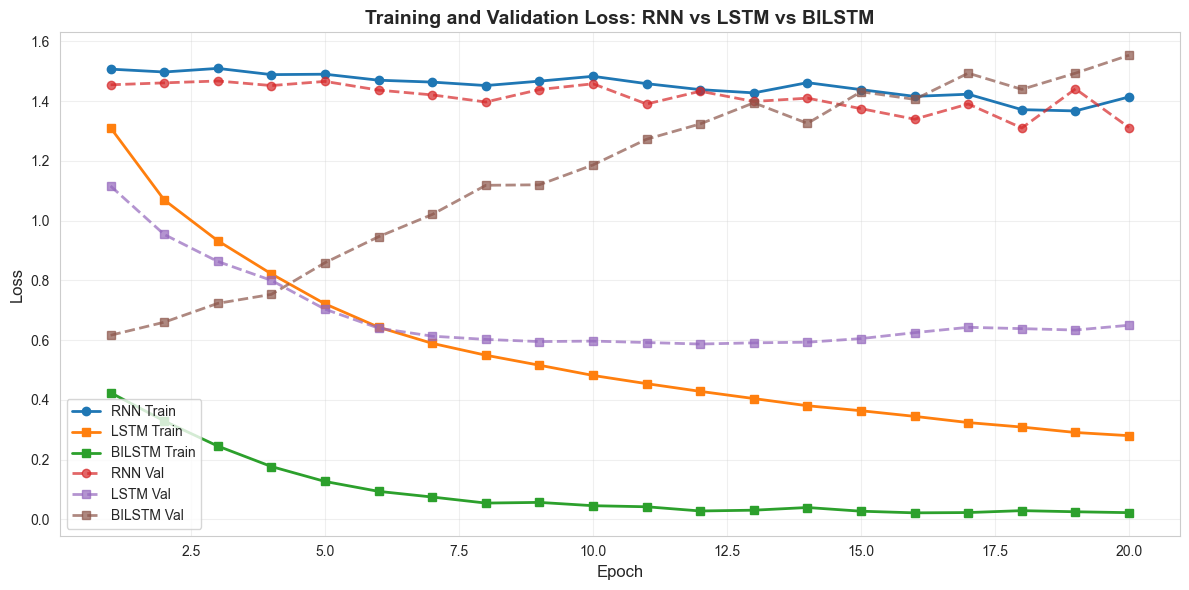

In [80]:
# Plot 1: Training Loss Comparison
fig, ax = plt.subplots(figsize=(12, 6))
epochs_range = range(1, EPOCHS + 1)

ax.plot(epochs_range, rnn_history['train_loss'], 'o-', label='RNN Train', linewidth=2)
ax.plot(epochs_range, lstm_history['train_loss'], 's-', label='LSTM Train', linewidth=2)
ax.plot(epochs_range, bilstm_history['train_loss'], 's-', label='BILSTM Train', linewidth=2)
ax.plot(epochs_range, rnn_history['val_loss'], 'o--', label='RNN Val', linewidth=2, alpha=0.7)
ax.plot(epochs_range, lstm_history['val_loss'], 's--', label='LSTM Val', linewidth=2, alpha=0.7)
ax.plot(epochs_range, bilstm_history['val_loss'], 's--', label='BILSTM Val', linewidth=2, alpha=0.7)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training and Validation Loss: RNN vs LSTM vs BILSTM', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_loss_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


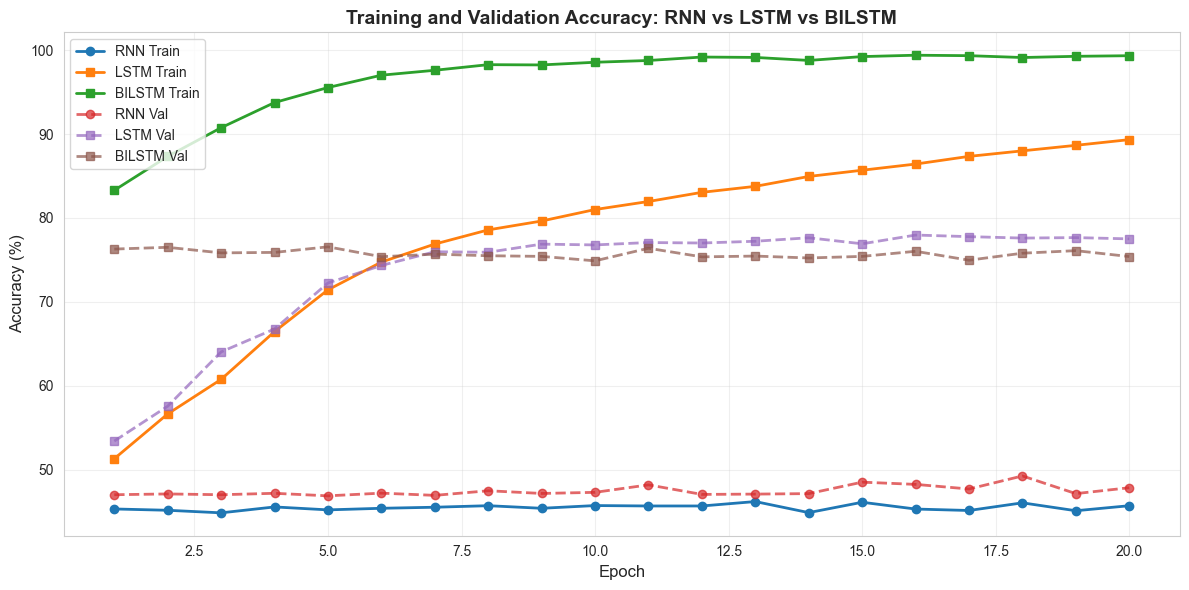

In [81]:
# Plot 2: Accuracy Comparison
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(epochs_range, rnn_history['train_acc'], 'o-', label='RNN Train', linewidth=2)
ax.plot(epochs_range, lstm_history['train_acc'], 's-', label='LSTM Train', linewidth=2)
ax.plot(epochs_range, bilstm_history['train_acc'], 's-', label='BILSTM Train', linewidth=2)
ax.plot(epochs_range, rnn_history['val_acc'], 'o--', label='RNN Val', linewidth=2, alpha=0.7)
ax.plot(epochs_range, lstm_history['val_acc'], 's--', label='LSTM Val', linewidth=2, alpha=0.7)
ax.plot(epochs_range, bilstm_history['val_acc'], 's--', label='BILSTM Val', linewidth=2, alpha=0.7)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Training and Validation Accuracy: RNN vs LSTM vs BILSTM', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

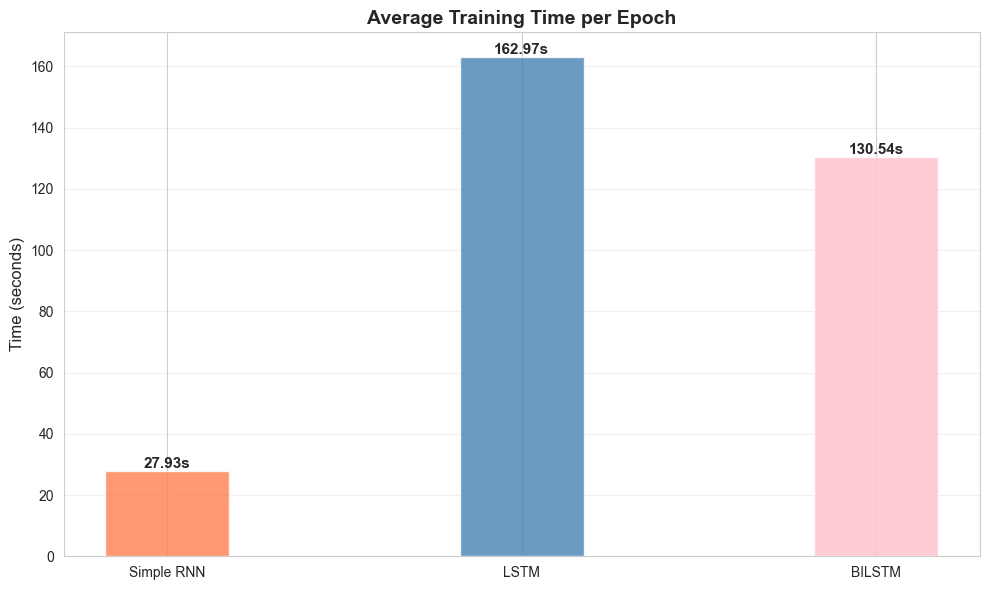


⏱️ RNN average time per epoch: 27.93s
⏱️ LSTM average time per epoch: 162.97s
⏱️ BILSTM average time per epoch: 130.54s
⏱️ LSTM is 483.5% slower (expected due to more gates)
⏱️ BILSTM is 367.4% slower (expected due to more gates)
⏱️ BILSTM is 24.8% slower


In [88]:
# Plot 4: Training Time per Epoch
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(3)
width = 0.35

rnn_avg_time = np.mean(rnn_history['train_time'])
lstm_avg_time = np.mean(lstm_history['train_time'])
bilstm_avg_time = np.mean(bilstm_history['train_time'])

bars = ax.bar(x, [rnn_avg_time, lstm_avg_time, bilstm_avg_time], width, 
              color=['coral', 'steelblue', 'pink'], alpha=0.8)

ax.set_ylabel('Time (seconds)', fontsize=12)
ax.set_title('Average Training Time per Epoch', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Simple RNN', 'LSTM', 'BILSTM'])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}s',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('06_training_time_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n⏱️ RNN average time per epoch: {rnn_avg_time:.2f}s")
print(f"⏱️ LSTM average time per epoch: {lstm_avg_time:.2f}s")
print(f"⏱️ BILSTM average time per epoch: {bilstm_avg_time:.2f}s")
print(f"⏱️ LSTM is {(lstm_avg_time/rnn_avg_time - 1)*100:.1f}% slower (expected due to more gates)")
print(f"⏱️ BILSTM is {(bilstm_avg_time/rnn_avg_time - 1)*100:.1f}% slower (expected due to more gates)")
print(f"⏱️ BILSTM is {(lstm_avg_time/bilstm_avg_time - 1)*100:.1f}% slower")


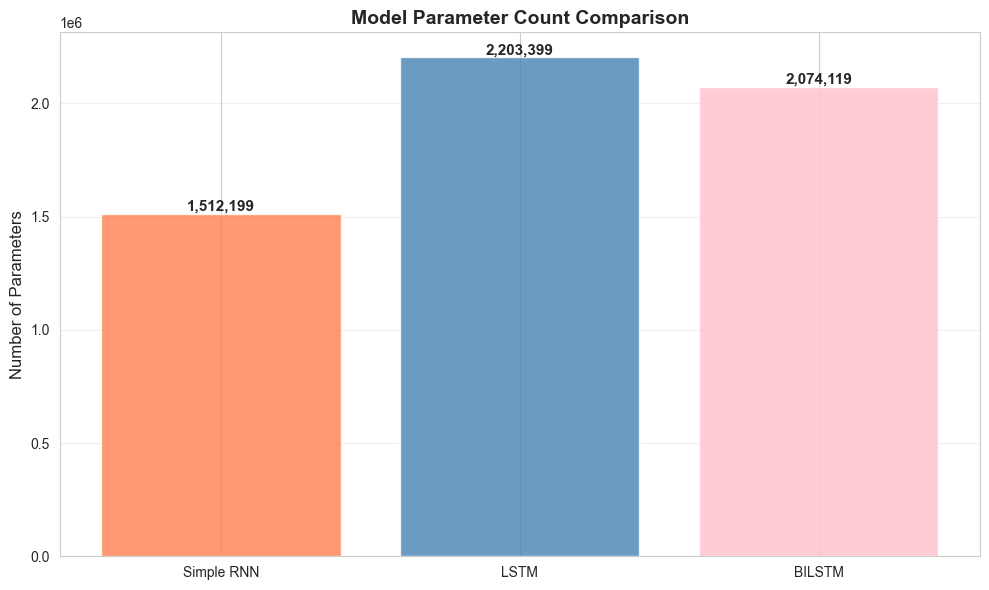


🔢 RNN parameters: 1,512,199
🔢 LSTM parameters: 2,203,399
🔢 BILSTM parameters: 2,074,119
🔢 LSTM has 45.7% more parameters (4x gates) than RNN


In [90]:
# Plot 5: Parameter Count Comparison
fig, ax = plt.subplots(figsize=(10, 6))

rnn_params = count_parameters(rnn_model)
lstm_params = count_parameters(lstm_model)
bilstm_params = count_parameters(bilstm_model)

bars = ax.bar(['Simple RNN', 'LSTM', 'BILSTM'], [rnn_params, lstm_params, bilstm_params], 
              color=['coral', 'steelblue', 'pink'], alpha=0.8)

ax.set_ylabel('Number of Parameters', fontsize=12)
ax.set_title('Model Parameter Count Comparison', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('07_parameter_count_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n🔢 RNN parameters: {rnn_params:,}")
print(f"🔢 LSTM parameters: {lstm_params:,}")
print(f"🔢 BILSTM parameters: {bilstm_params:,}")
print(f"🔢 LSTM has {(lstm_params/rnn_params - 1)*100:.1f}% more parameters (4x gates) than RNN")


## Test Set Evaluation

In [107]:
def detailed_evaluation(model, dataloader, model_name, label_decoder):
    """Comprehensive evaluation with metrics"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for sequences, labels in dataloader:
            sequences = sequences.to(device)
            labels = labels.to(device)
            
            outputs = model(sequences)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    print(f"\n{'=' * 60}")
    print(f"{model_name} - Test Set Evaluation")
    print(f"{'=' * 60}")
    print(f"Accuracy:  {accuracy*100:.2f}%")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    # Classification report
    print(f"\n📊 Classification Report:")
    target_names = [label_decoder[i] for i in sorted(label_decoder.keys())]
    print(classification_report(all_labels, all_preds, target_names=target_names))
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm,
        'predictions': all_preds,
        'labels': all_labels
    }

In [108]:
# Evaluate both models
rnn_results = detailed_evaluation(rnn_model, test_loader, "Simple RNN", label_decoder)
lstm_results = detailed_evaluation(lstm_model, test_loader, "LSTM", label_decoder)
bilstm_results = detailed_evaluation(bilstm_model, test_loader, "BILSTM", label_decoder)



Simple RNN - Test Set Evaluation
Accuracy:  47.47%
Precision: 0.3133
Recall:    0.4747
F1-Score:  0.3663

📊 Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.36      0.20      0.26       384
              Normal       0.49      0.98      0.65      1635
          Depression       0.46      0.54      0.50      1541
            Suicidal       0.00      0.00      0.00      1066
              Stress       0.00      0.00      0.00       258
             Bipolar       0.00      0.00      0.00       278
Personality disorder       0.00      0.00      0.00       107

            accuracy                           0.47      5269
           macro avg       0.19      0.25      0.20      5269
        weighted avg       0.31      0.47      0.37      5269


LSTM - Test Set Evaluation
Accuracy:  77.34%
Precision: 0.7796
Recall:    0.7734
F1-Score:  0.7744

📊 Classification Report:
                      precision    recall  f1-score   sup

# xLSTM

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [7]:
class xLSTMCell(nn.Module):
    """
    A simple "extended LSTM" cell:
    - Standard LSTM gates (i, f, o)
    - Candidate update is richer: gated MLP (like a tiny feedforward block)
    - LayerNorm on the cell/hidden improves stability
    """
    def __init__(self, input_dim, hidden_dim, dropout):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        # Gates: i, f, o (input, forget, output)
        self.gates = nn.Linear(input_dim + hidden_dim, 3 * hidden_dim)

        # Rich candidate: two-layer MLP with gating
        self.cand_fc1 = nn.Linear(input_dim + hidden_dim, 2 * hidden_dim)
        self.cand_fc2 = nn.Linear(hidden_dim, hidden_dim)

        self.ln_c = nn.LayerNorm(hidden_dim)
        self.ln_h = nn.LayerNorm(hidden_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x_t, state):
        """
        x_t: (B, input_dim)
        state: (h, c) each (B, hidden_dim)
        """
        h, c = state
        z = torch.cat([x_t, h], dim=-1)

        # LSTM-style gates
        i, f, o = self.gates(z).chunk(3, dim=-1)
        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)

        # Extended candidate (gated MLP)
        a, b = self.cand_fc1(z).chunk(2, dim=-1)
        # b gates a (GLU-like)
        cand = torch.tanh(a) * torch.sigmoid(b)
        cand = self.cand_fc2(self.dropout(cand))

        # Cell update
        c = f * c + i * cand
        c = self.ln_c(c)

        # Hidden update
        h = o * torch.tanh(c)
        h = self.ln_h(h)

        return h, c

In [8]:
class XLSTMLayer(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout):
        super().__init__()
        self.cell = xLSTMCell(input_dim, hidden_dim, dropout=dropout)
        
    
    def forward(self, x, state=None):
        """ 
        x: (B, T, input_dim)
        returns:
            outputs= (B, T, hidden_dim)
            (h, c): final state
        """
        B, T, _ = x.shape
        device = x.device

        if state is None:
            h = torch.zeros(B, self.cell.hidden_dim, device=device)
            c = torch.zeros(B, self.cell.hidden_dim, device=device)
        else:
            h, c = state

        outs = []
        for t in range(T):
            h, c = self.cell(x[:, t, :], (h, c))
            outs.append(h.unsqueeze(1))
        
        outputs = torch.cat(outs, dim=1)
        return outputs, (h, c)

In [9]:
class xLSTMTextClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, dropout=0.3, padding_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx)
        self.xlstm = XLSTMLayer(embedding_dim, hidden_dim, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    
    def forward(self, x):
        # x: (B, T)
        emb = self.embedding(x)
        out, (h, c) = self.xlstm(emb)
        h = self.dropout(h)
        logits = self.fc(h)
        return logits

In [ ]:
model = xLSTMTextClassifier(
    vocab_size=20000,
    embedding_dim=200,
    hidden_dim=256,
    num_classes=7,
    dropout=0.3,
    padding_idx=0
)

x = torch.randint(0, 20000, (32, 100)) # (batch=32, seq_len=100)
logits = model(x)
print(logits.shape)

torch.Size([32, 7])


tensor([[ 9.3207e-01, -6.1396e-01,  7.0505e-01, -9.1194e-02, -6.7940e-01,
          4.0021e-01, -3.9201e-01],
        [ 1.3442e-01,  3.0143e-01,  1.7954e+00,  5.3572e-01, -8.6532e-02,
          5.7530e-03,  9.1952e-01],
        [ 5.4770e-01,  2.2421e-01,  4.8255e-01, -3.9668e-02,  1.8499e+00,
          4.9554e-02,  3.7429e-01],
        [ 8.1930e-01,  4.7833e-01,  4.2180e-01, -6.4606e-01,  1.2130e+00,
         -2.6184e-01,  5.0043e-01],
        [ 1.4786e-01,  1.4904e+00,  7.1601e-02, -9.1230e-01,  1.0804e+00,
          1.0503e-01, -8.7578e-02],
        [-2.8408e-01,  5.4078e-01,  4.8820e-01, -2.7126e-01,  9.3200e-01,
         -6.2229e-01, -1.6928e-01],
        [ 5.7435e-02, -5.8333e-01,  7.2771e-01, -1.0349e+00,  1.3486e-01,
          4.1413e-01, -5.1245e-01],
        [ 6.9738e-01,  1.7053e-01,  8.0395e-01,  7.4231e-01,  7.1638e-01,
          2.8299e-01, -3.5748e-01],
        [ 1.4062e+00,  3.2362e-01,  1.3327e-01, -2.5855e-01, -2.2978e-01,
          4.1421e-03, -1.0528e+00],
        [ 

# Full Project: RNN, xLSTM, BILSTM, xBILSTM

- Columns: `Unnamed: 0`, `statement`, `status`
- This is a text classification dataset
- `status` is the label column
- At least one label is `Anxiety`
- The dataset is large: about **53 rows**

#### What the models will do on this dataset

`TASK`:
    **Input**: a text statement
    **Output**: one of the `status` classes

`PIPELINE`:
 1. Clean text
 2. Tokenize
 3. Convert text to Sequences
 4. Build model
 5. Train
 6. Evaluation(Compare validation loss/accuracy/F1)


 #### RNN

- Simplest recurrent model
- Fastest and easiest
- Often struggles with long text because it forgets earlier words

 #### BiLSTM

- Reads text forward and backward
- Usually better than RNN for classification
- More expensive than RNN, but strong baseline

 #### xLSTM

 - `Extended LSTM`
 - Still has memory gates like LSTM
 - But uses a stronger internal update
 - Usually helps when the text has more complex patterns

A simple xLSTM-style block:
- standard LSTM gates
- plus:
    - LayerNorm
    - gated MLP candidate update
    - residual-style stabilization


 #### xBiLSTM

- Bidirectional version of xLSTM
- Combines:
    - forward xLSTM
    - bacward xLSTM
- Usually the strongest among these four for classification, but also the heaviest

## Load and Preprocess the CSV

In [115]:
import re
import math
import random
import numpy as np
import pandas as pd
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


In [116]:
df = pd.read_csv("dataset/Combined Data.csv")

# Keep only needed columns
df = df[["statement", "status"]].copy()

# Drop missing statements / labels
df = df.dropna(subset=["statement", "status"])

# Remove empty strings
df["statement"] = df["statement"].astype(str).str.strip()
df = df[df["statement"] != ""]

print(df.shape)
print(df["status"].value_counts())
print(df["status"].unique())


(52681, 2)
status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64
<StringArray>
[             'Anxiety',               'Normal',           'Depression',
             'Suicidal',               'Stress',              'Bipolar',
 'Personality disorder']
Length: 7, dtype: str


In [117]:
labels = sorted(df["status"].unique().tolist())
label2idx = {label: i for i, label in enumerate(labels)}
idx2label = {i: label for label, i in label2idx.items()}

df["label"] = df["status"].map(label2idx)

num_classes = len(labels)
print("Labels:", labels)
print("Num classes:", num_classes)


Labels: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']
Num classes: 7


In [118]:
X = df["statement"].tolist()
y = df["label"].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(len(X_train), len(X_val), len(X_test))


42144 5268 5269


In [119]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|@\S+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()


In [120]:
def build_vocab(texts, min_freq=2, max_size=50000):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))

    vocab = {
        "<pad>": 0,
        "<unk>": 1
    }

    for word, freq in counter.most_common(max_size):
        if freq >= min_freq:
            vocab[word] = len(vocab)

    return vocab


In [121]:
vocab = build_vocab(X_train, min_freq=2, max_size=50000)

pad_idx = vocab["<pad>"]
unk_idx = vocab["<unk>"]

print("Vocab size:", len(vocab))


Vocab size: 26194


In [122]:
def encode(text, vocab, max_len=80):
    tokens = tokenize(text)
    ids = [vocab.get(tok, unk_idx) for tok in tokens]
    ids = ids[:max_len]
    if len(ids) < max_len:
        ids += [pad_idx] * (max_len - len(ids))
    return ids


In [123]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=80):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = encode(self.texts[idx], self.vocab, self.max_len)
        y = self.labels[idx]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)


In [124]:
batch_size = 64

train_dataset = TextDataset(X_train, y_train, vocab)
val_dataset = TextDataset(X_val, y_val, vocab)
test_dataset = TextDataset(X_test, y_test, vocab)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


In [125]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        out, h = self.rnn(x)
        h = h[-1]
        return self.fc(h)


In [126]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        out, (h, c) = self.lstm(x)
        h = h[-1]
        return self.fc(h)


In [127]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        out, (h, c) = self.lstm(x)
        h_forward = h[-2]
        h_backward = h[-1]
        h = torch.cat((h_forward, h_backward), dim=1)
        return self.fc(h)


In [128]:
class xLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim

        self.linear = nn.Linear(input_dim + hidden_dim, 4 * hidden_dim)

    def forward(self, x, h_prev, c_prev):
        combined = torch.cat([x, h_prev], dim=1)
        gates = self.linear(combined)
        i, f, g, o = gates.chunk(4, dim=1)

        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)

        c = f * c_prev + i * g
        h = o * torch.tanh(c)

        return h, c


In [129]:
class xLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.cell = xLSTMCell(embed_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, num_classes)
        self.hidden_dim = hidden_dim

    def forward(self, x):
        x = self.embedding(x)
        batch_size, seq_len, _ = x.size()

        h = torch.zeros(batch_size, self.hidden_dim).to(x.device)
        c = torch.zeros(batch_size, self.hidden_dim).to(x.device)

        for t in range(seq_len):
            h, c = self.cell(x[:, t, :], h, c)

        return self.fc(h)


In [130]:
class xBiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.forward_cell = xLSTMCell(embed_dim, hidden_dim)
        self.backward_cell = xLSTMCell(embed_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        self.hidden_dim = hidden_dim

    def forward(self, x):
        x = self.embedding(x)
        batch_size, seq_len, _ = x.size()

        hf = torch.zeros(batch_size, self.hidden_dim).to(x.device)
        cf = torch.zeros(batch_size, self.hidden_dim).to(x.device)

        hb = torch.zeros(batch_size, self.hidden_dim).to(x.device)
        cb = torch.zeros(batch_size, self.hidden_dim).to(x.device)

        for t in range(seq_len):
            hf, cf = self.forward_cell(x[:, t, :], hf, cf)

        for t in reversed(range(seq_len)):
            hb, cb = self.backward_cell(x[:, t, :], hb, cb)

        h = torch.cat([hf, hb], dim=1)
        return self.fc(h)


In [131]:
def train_model(model, train_loader, val_loader, epochs=3, lr=1e-3, device="cpu"):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.to(device)

    best_val_acc = 0
    best_state = None

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        val_acc = evaluate_model(model, val_loader, device=device)
        avg_loss = total_loss / len(train_loader)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = model.state_dict()

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


In [132]:
def evaluate_model(model, loader, device="cpu"):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(x_batch)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    return accuracy_score(all_targets, all_preds)


In [133]:
def get_metrics(model, loader, device="cpu"):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(x_batch)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    acc = accuracy_score(all_targets, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_targets, all_preds, average="weighted", zero_division=0
    )

    return acc, precision, recall, f1


In [134]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cpu


In [137]:
vocab_size = len(vocab)
embed_dim = 128
hidden_dim = 128
epochs = 10


In [138]:
results = []

models = {
    "RNN": RNNClassifier(vocab_size, embed_dim, hidden_dim, num_classes, pad_idx),
    "LSTM": LSTMClassifier(vocab_size, embed_dim, hidden_dim, num_classes, pad_idx),
    "BiLSTM": BiLSTMClassifier(vocab_size, embed_dim, hidden_dim, num_classes, pad_idx),
    "xLSTM": xLSTMClassifier(vocab_size, embed_dim, hidden_dim, num_classes, pad_idx),
    "xBiLSTM": xBiLSTMClassifier(vocab_size, embed_dim, hidden_dim, num_classes, pad_idx),
}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model = train_model(model, train_loader, val_loader, epochs=epochs, device=device)
    acc, prec, rec, f1 = get_metrics(model, test_loader, device=device)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    })



Training RNN...
Epoch 1/10 | Loss: 1.4628 | Val Acc: 0.4789
Epoch 2/10 | Loss: 1.5345 | Val Acc: 0.4153
Epoch 3/10 | Loss: 1.4379 | Val Acc: 0.3937
Epoch 4/10 | Loss: 1.4405 | Val Acc: 0.4831
Epoch 5/10 | Loss: 1.4105 | Val Acc: 0.4787
Epoch 6/10 | Loss: 1.3753 | Val Acc: 0.4804
Epoch 7/10 | Loss: 1.3450 | Val Acc: 0.4738
Epoch 8/10 | Loss: 1.3055 | Val Acc: 0.4806
Epoch 9/10 | Loss: 1.2242 | Val Acc: 0.5287
Epoch 10/10 | Loss: 1.3053 | Val Acc: 0.4816

Training LSTM...
Epoch 1/10 | Loss: 1.2735 | Val Acc: 0.5573
Epoch 2/10 | Loss: 1.0299 | Val Acc: 0.6124
Epoch 3/10 | Loss: 0.8943 | Val Acc: 0.6695
Epoch 4/10 | Loss: 0.7490 | Val Acc: 0.7107
Epoch 5/10 | Loss: 0.6211 | Val Acc: 0.7316
Epoch 6/10 | Loss: 0.5224 | Val Acc: 0.7268
Epoch 7/10 | Loss: 0.4392 | Val Acc: 0.7380
Epoch 8/10 | Loss: 0.3625 | Val Acc: 0.7329
Epoch 9/10 | Loss: 0.2929 | Val Acc: 0.7350
Epoch 10/10 | Loss: 0.2341 | Val Acc: 0.7303

Training BiLSTM...
Epoch 1/10 | Loss: 1.0491 | Val Acc: 0.6585
Epoch 2/10 | Loss: 

In [139]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1", ascending=False)

print(results_df)

     Model  Accuracy  Precision    Recall        F1
2   BiLSTM  0.730689   0.739085  0.730689  0.733458
4  xBiLSTM  0.734105   0.731865  0.734105  0.732336
1     LSTM  0.734485   0.736406  0.734485  0.732165
3    xLSTM  0.731069   0.728382  0.731069  0.727940
0      RNN  0.479218   0.398157  0.479218  0.400355


In [140]:
best_model_name = results_df.iloc[0]["Model"]
print("Best model:", best_model_name)


Best model: BiLSTM


# Use GloVe

In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import matplotlib.pyplot as plt
import re

In [42]:
gdf = pd.read_csv('dataset/Combined Data.csv')
gdf.drop(columns=['Unnamed: 0'], inplace=True)
gdf.dropna(inplace=True)
texts = gdf['statement'].astype(str).tolist()
labels = gdf['status'].tolist()
gdf.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [45]:
label_map = {label: idx for idx, label in enumerate(sorted(set(labels)))}
y = [label_map[label] for label in labels]
num_classes = len(label_map)

In [47]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z ]", "", text)
    return text

texts = [clean_text(t) for t in texts]

In [48]:
def tokenize(text):
    return text.split()

tokenized = [tokenize(t) for t in texts]


In [52]:
counter = Counter()
for tokens in tokenized:
    counter.update(tokens)

vocab = {'<pad>': 0, '<unk>': 1}

for word, freq in counter.items():
    if freq > 2:
        vocab[word] = len(vocab)
vocab_size = len(vocab)

In [75]:
def encode(tokens, max_len=40):
    ids = [vocab.get(t,1) for t in tokens]
    
    if len(ids) < max_len:
        ids += [0]*(max_len-len(ids))
    else:
        ids = ids[:max_len]
        
    return ids

X = [encode(tokens) for tokens in tokenized]


In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [77]:
class TextDataset(Dataset):
    
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [78]:
train_dataset = TextDataset(X_train, y_train)
test_dataset = TextDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)


In [65]:
def load_glove(path, vocab, dim=100):

    embeddings = np.random.uniform(-0.25,0.25,(len(vocab),dim))

    with open(path, encoding="utf8") as f:
        for line in f:
            values = line.split()
            word = values[0]

            if word in vocab:
                vector = np.asarray(values[1:], dtype='float32')
                embeddings[vocab[word]] = vector

    return torch.tensor(embeddings, dtype=torch.float32)


embedding_matrix = load_glove("dataset/glove.6B.100d.txt", vocab, 100)


In [66]:
embedding_layer = nn.Embedding.from_pretrained(
    embedding_matrix,
    freeze=True
)

In [69]:
class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = embedding_layer
        self.rnn = nn.RNN(100,128,batch_first=True)
        self.fc = nn.Linear(128,num_classes)

    def forward(self,x):
        x = self.embedding(x)
        out,_ = self.rnn(x)
        out = out[:,-1,:]
        return self.fc(out)
    


class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = embedding_layer
        self.lstm = nn.LSTM(100,128,batch_first=True)
        self.fc = nn.Linear(128,num_classes)

    def forward(self,x):
        x = self.embedding(x)
        out,_ = self.lstm(x)
        out = out[:,-1,:]
        return self.fc(out)
    


class BiLSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = embedding_layer
        self.lstm = nn.LSTM(
            100,
            128,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(256,num_classes)

    def forward(self,x):
        x = self.embedding(x)
        out,_ = self.lstm(x)
        out = out[:,-1,:]
        return self.fc(out)


class xLSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = embedding_layer
        self.lstm = nn.LSTM(
            100,
            128,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )
        self.fc = nn.Linear(128,num_classes)

    def forward(self,x):
        x = self.embedding(x)
        out,_ = self.lstm(x)
        out = out[:,-1,:]
        return self.fc(out)



class xBiLSTMModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.embedding = embedding_layer
        self.lstm = nn.LSTM(
            100,
            128,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.fc = nn.Linear(256,num_classes)

    def forward(self,x):
        x = self.embedding(x)
        out,_ = self.lstm(x)
        out = out[:,-1,:]
        return self.fc(out)




In [70]:
def train_model(model, epochs=5):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses = []

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for x,y in train_loader:

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            output = model(x)

            loss = criterion(output,y)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        avg = total_loss/len(train_loader)

        train_losses.append(avg)

        print("Epoch:",epoch+1,"Loss:",avg)

    return train_losses


In [71]:
def evaluate(model):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x,y in test_loader:

            x = x.to(device)
            y = y.to(device)

            out = model(x)

            preds = torch.argmax(out,dim=1)

            correct += (preds==y).sum().item()

            total += y.size(0)

    acc = correct/total

    print("Test Accuracy:",acc)

    return acc


In [79]:
rnn_model = RNNModel()

loss = train_model(rnn_model, epochs=10)
acc = evaluate(rnn_model)


Epoch: 1 Loss: 1.3571397690201386
Epoch: 2 Loss: 1.3221896118929606
Epoch: 3 Loss: 1.3091346764419798
Epoch: 4 Loss: 1.2958964911686632
Epoch: 5 Loss: 1.2876030461741146
Epoch: 6 Loss: 1.2851963053162072
Epoch: 7 Loss: 1.2849054414332366
Epoch: 8 Loss: 1.2857067943162006
Epoch: 9 Loss: 1.2876067750370737
Epoch: 10 Loss: 1.2830513023823635
Test Accuracy: 0.5302268197779254


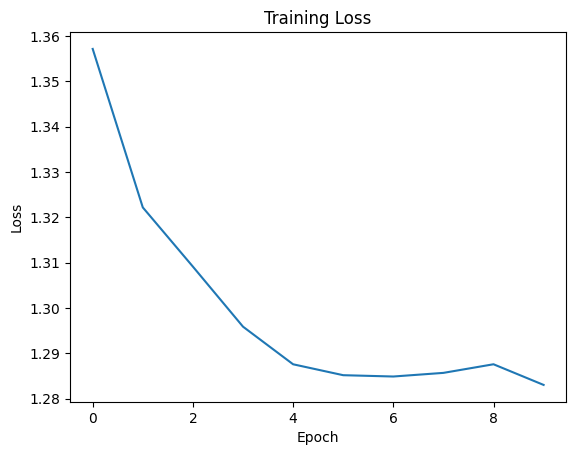

In [80]:
plt.plot(loss)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [82]:
rnn_model = LSTMModel()

loss = train_model(rnn_model, epochs=20)
acc = evaluate(rnn_model)

Epoch: 1 Loss: 1.1197944458952804
Epoch: 2 Loss: 0.8518189934841237
Epoch: 3 Loss: 0.7515070885193728
Epoch: 4 Loss: 0.6971015397894545
Epoch: 5 Loss: 0.6609235386928043
Epoch: 6 Loss: 0.6291677531685923
Epoch: 7 Loss: 0.6030949290406541
Epoch: 8 Loss: 0.5753952910578124
Epoch: 9 Loss: 0.5501188295744981
Epoch: 10 Loss: 0.5213866431452616
Epoch: 11 Loss: 0.49523004568400986
Epoch: 12 Loss: 0.4653414630066824
Epoch: 13 Loss: 0.4363873136287756
Epoch: 14 Loss: 0.40913998537975305
Epoch: 15 Loss: 0.3846169858040325
Epoch: 16 Loss: 0.3592020189997278
Epoch: 17 Loss: 0.33527649416728156
Epoch: 18 Loss: 0.3158718161454512
Epoch: 19 Loss: 0.2907377977336846
Epoch: 20 Loss: 0.26880438476574803
Test Accuracy: 0.7362626933662333


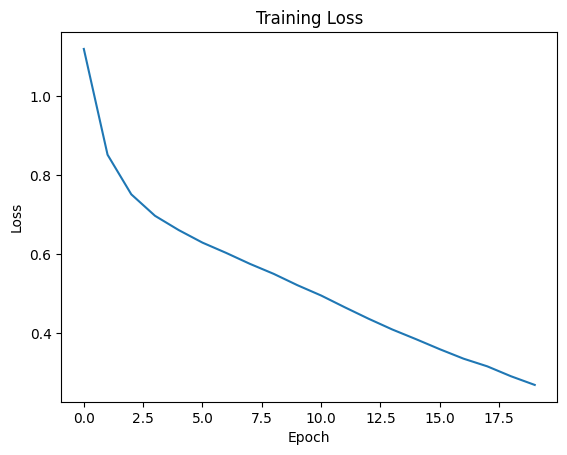

In [83]:
plt.plot(loss)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [84]:
rnn_model = BiLSTMModel()

loss = train_model(rnn_model, epochs=20)
acc = evaluate(rnn_model)

Epoch: 1 Loss: 1.165583604746053
Epoch: 2 Loss: 0.875079266489547
Epoch: 3 Loss: 0.7510796383317215
Epoch: 4 Loss: 0.6931829301920213
Epoch: 5 Loss: 0.6547317543322834
Epoch: 6 Loss: 0.6237274968660294
Epoch: 7 Loss: 0.5957003706141922
Epoch: 8 Loss: 0.568509139810238
Epoch: 9 Loss: 0.5402560544755644
Epoch: 10 Loss: 0.5100458407709558
Epoch: 11 Loss: 0.48577185884140694
Epoch: 12 Loss: 0.4564265341290212
Epoch: 13 Loss: 0.4308424725427613
Epoch: 14 Loss: 0.4020363653420678
Epoch: 15 Loss: 0.38295505106539574
Epoch: 16 Loss: 0.35566685396233894
Epoch: 17 Loss: 0.3338538931515944
Epoch: 18 Loss: 0.3111834296213296
Epoch: 19 Loss: 0.2881621730164801
Epoch: 20 Loss: 0.27407673010334077
Test Accuracy: 0.7297143399449558
